<a href="https://www.kaggle.com/code/pavankumar960/ipl-2026-comprehensive-eda-ml-win-predictor?scriptVersionId=309721116" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Project Setup

In [1]:
# Basic Libs
import numpy as np 
import pandas as pd 

# Visualization Libs
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid", font_scale=1.1)

# Loading Dataset

In [2]:
mat = pd.read_csv("/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/matches.csv")
deli = pd.read_csv("/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/deliveries.csv")
poi = pd.read_csv("/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/points_table.csv")
sqd = pd.read_csv("/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/squads.csv")
ven = pd.read_csv("/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/venues.csv")
ocap = pd.read_csv("/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/orange_cap.csv")
pcap = pd.read_csv("/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/purple_cap.csv")

# Data Overview

In [3]:
my_list = [mat, deli, poi, sqd, ven, ocap, pcap]

[i.shape for i in my_list]

[(7, 22), (1382, 19), (10, 9), (257, 6), (12, 5), (15, 16), (15, 14)]

In [4]:
for i in my_list:
    print(i.info())
    print("-" * 50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             7 non-null      int64  
 1   date                 7 non-null      object 
 2   venue                7 non-null      object 
 3   team1                7 non-null      object 
 4   team2                7 non-null      object 
 5   stage                7 non-null      object 
 6   toss_winner          7 non-null      object 
 7   toss_decision        7 non-null      object 
 8   first_ings_score     7 non-null      int64  
 9   first_ings_wkts      7 non-null      int64  
 10  second_ings_score    7 non-null      int64  
 11  second_ings_wkts     7 non-null      int64  
 12  match_result         7 non-null      object 
 13  match_winner         7 non-null      object 
 14  wb_runs              1 non-null      float64
 15  wb_wickets           6 non-null      float64

In [5]:
[i.head()for i in my_list]

[   match_id            date                               venue team1 team2  \
 0         1  March 28, 2026   M. Chinnaswamy Stadium, Bangalore   RCB   SRH   
 1         2  March 29, 2026            Wankhede Stadium, Mumbai    MI   KKR   
 2         3  March 30, 2026         Barsapara Stadium, Guwahati    RR   CSK   
 3         4  March 31, 2026  New PCA Cricket Stadium, Mullanpur  PBKS    GT   
 4         5  April 01, 2026      Ekana Cricket Stadium, Lucknow   LSG    DC   
 
     stage toss_winner toss_decision  first_ings_score  first_ings_wkts  ...  \
 0  League         RCB          Bowl               201                9  ...   
 1  League          MI          Bowl               220                4  ...   
 2  League          RR          Bowl               127               10  ...   
 3  League        PBKS          Bowl               162                6  ...   
 4  League          DC          Bowl               141               10  ...   
 
    match_result  match_winner wb_ru

In [6]:
[i.isnull().sum() for i in my_list]

[match_id               0
 date                   0
 venue                  0
 team1                  0
 team2                  0
 stage                  0
 toss_winner            0
 toss_decision          0
 first_ings_score       0
 first_ings_wkts        0
 second_ings_score      0
 second_ings_wkts       0
 match_result           0
 match_winner           0
 wb_runs                6
 wb_wickets             1
 balls_left             0
 player_of_the_match    0
 top_scorer             0
 highscore              0
 best_bowling           0
 best_bowling_figure    0
 dtype: int64,
 match_no               0
 date                   0
 stage                  0
 venue                  0
 batting_team           0
 bowling_team           0
 innings                0
 over                   0
 striker                0
 bowler                 0
 runs_of_bat            0
 extras                 0
 wide                   0
 legbyes                0
 byes                   0
 noballs               

In [7]:
[i.duplicated().sum() for i in my_list]

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(166),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

In [8]:
[i.nunique() for i in my_list]

[match_id               7
 date                   7
 venue                  7
 team1                  7
 team2                  6
 stage                  1
 toss_winner            6
 toss_decision          1
 first_ings_score       7
 first_ings_wkts        6
 second_ings_score      7
 second_ings_wkts       5
 match_result           1
 match_winner           6
 wb_runs                1
 wb_wickets             4
 balls_left             6
 player_of_the_match    7
 top_scorer             7
 highscore              6
 best_bowling           7
 best_bowling_figure    7
 dtype: int64,
 match_no              6
 date                  6
 stage                 1
 venue                 6
 batting_team         10
 bowling_team         10
 innings               2
 over                120
 striker              84
 bowler               62
 runs_of_bat           6
 extras                5
 wide                  2
 legbyes               2
 byes                  2
 noballs               2
 wicket_type 

In [9]:
[i.dtypes for i in my_list]

[match_id                 int64
 date                    object
 venue                   object
 team1                   object
 team2                   object
 stage                   object
 toss_winner             object
 toss_decision           object
 first_ings_score         int64
 first_ings_wkts          int64
 second_ings_score        int64
 second_ings_wkts         int64
 match_result            object
 match_winner            object
 wb_runs                float64
 wb_wickets             float64
 balls_left               int64
 player_of_the_match     object
 top_scorer              object
 highscore                int64
 best_bowling            object
 best_bowling_figure     object
 dtype: object,
 match_no              int64
 date                 object
 stage                object
 venue                object
 batting_team         object
 bowling_team         object
 innings               int64
 over                float64
 striker              object
 bowler            

In [10]:
for i in my_list: print(i.describe())

       match_id  first_ings_score  first_ings_wkts  second_ings_score  \
count  7.000000          7.000000         7.000000           7.000000   
mean   4.000000        183.714286         7.428571         176.571429   
std    2.160247         39.907035         2.439750          36.050230   
min    1.000000        127.000000         4.000000         128.000000   
25%    2.500000        151.500000         5.500000         153.000000   
50%    4.000000        201.000000         8.000000         165.000000   
75%    5.500000        214.500000         9.500000         206.500000   
max    7.000000        226.000000        10.000000         224.000000   

       second_ings_wkts  wb_runs  wb_wickets  balls_left  highscore  
count          7.000000      1.0    6.000000    7.000000   7.000000  
mean           5.142857     65.0    5.666667   18.857143  68.571429  
std            2.609506      NaN    1.632993   15.137465  12.025766  
min            2.000000     65.0    3.000000    5.000000  52.0

In [11]:
[i.corr(numeric_only=True) for i in my_list]

[                   match_id  first_ings_score  first_ings_wkts  \
 match_id           1.000000          0.096664        -0.126491   
 first_ings_score   0.096664          1.000000        -0.614782   
 first_ings_wkts   -0.126491         -0.614782         1.000000   
 second_ings_score -0.188330          0.778404        -0.759329   
 second_ings_wkts   0.502616          0.523803        -0.220647   
 wb_runs                 NaN               NaN              NaN   
 wb_wickets        -0.321270         -0.277795         0.537508   
 balls_left        -0.234450         -0.455860         0.791682   
 highscore         -0.391347          0.300104        -0.503946   
 
                    second_ings_score  second_ings_wkts  wb_runs  wb_wickets  \
 match_id                   -0.188330          0.502616      NaN   -0.321270   
 first_ings_score            0.778404          0.523803      NaN   -0.277795   
 first_ings_wkts            -0.759329         -0.220647      NaN    0.537508   
 second_

# Data Cleaning

## Handling Duplicates

In [12]:
sqd = sqd.drop_duplicates(keep='first').reset_index(drop=True)
print("Duplicates left in squads:", sqd.duplicated().sum())

Duplicates left in squads: 0


## Handling Missing Values

In [13]:
mat = mat.fillna({'wb_runs': 0, 'wb_wickets': 0})

In [14]:
deli = deli.fillna({
    'wicket_type': 'None', 
    'player_dismissed': 'None', 
    'fielder': 'None'
})

In [15]:
sqd = sqd.dropna(subset=['player']).reset_index(drop=True)

In [16]:
print("Nulls in Matches:", mat[['wb_runs', 'wb_wickets']].isnull().sum().sum())
print("Nulls in Deliveries:", deli[['wicket_type']].isnull().sum().sum())
print("Nulls in Squads:", sqd['player'].isnull().sum())

Nulls in Matches: 0
Nulls in Deliveries: 0
Nulls in Squads: 0


# Data Visualization

## Toss Advantage

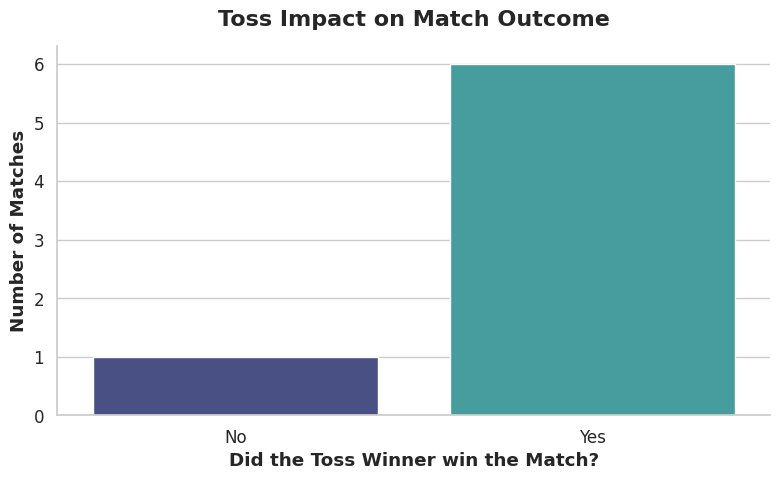

In [17]:
mat['toss_win_match_win'] = mat['toss_winner'] == mat['match_winner']

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x='toss_win_match_win', 
    data=mat, 
    hue='toss_win_match_win', 
    palette='mako', 
    legend=False
)

plt.title('Toss Impact on Match Outcome', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Did the Toss Winner win the Match?', fontweight='bold')
plt.ylabel('Number of Matches', fontweight='bold')
plt.xticks([0, 1], ['No', 'Yes'])

sns.despine()
plt.tight_layout()
plt.show()

**Observation**

* A 6:1 win ratio for toss winners is a massive statistical bias. It means the conditions (like evening dew making the ball wet, or the pitch slowing down) heavily favor whoever gets to choose what to do first.
* The data shows a strong 'Win Toss, Win Match' bias.

## Venue Analysis

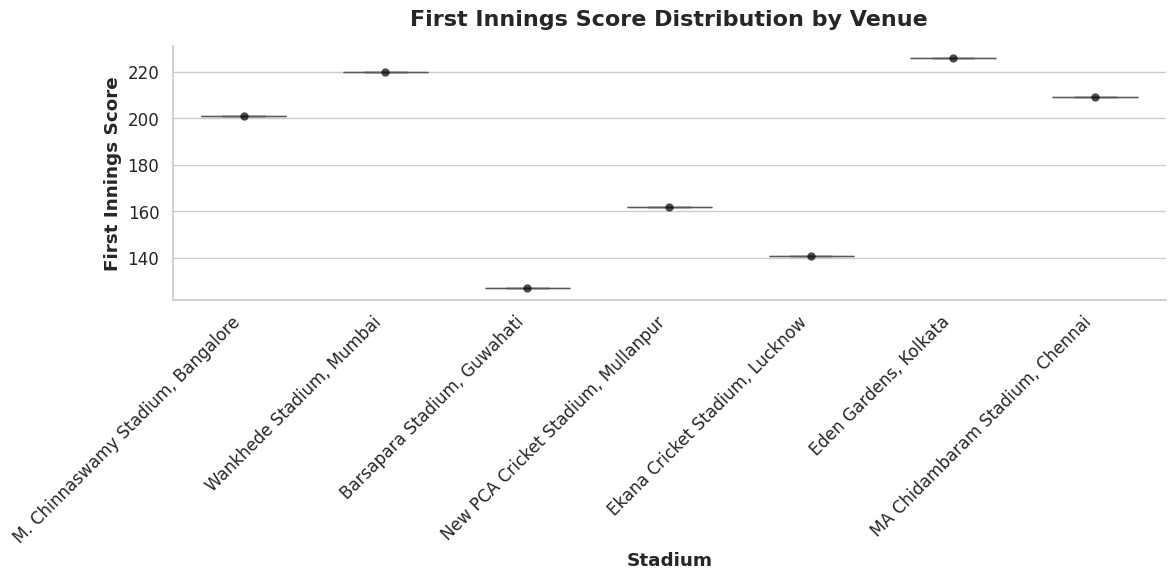

In [18]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='venue', 
    y='first_ings_score', 
    data=mat, 
    hue='venue', 
    palette='coolwarm', 
    legend=False,
    width=0.6,
    boxprops={'alpha': 0.6}
)

sns.swarmplot(
    x='venue', 
    y='first_ings_score', 
    data=mat, 
    color="black", 
    alpha=0.7,
    size=6
)

plt.title('First Innings Score Distribution by Venue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Stadium', fontweight='bold')
plt.ylabel('First Innings Score', fontweight='bold')
plt.xticks(rotation=45, ha='right')

sns.despine()
plt.tight_layout()
plt.show()

**Observation**
* identified a huge gap. Kolkata, Mumbai, Chennai, and Bangalore are absolute batting paradises (all 200+). Meanwhile, Mullanpur, Lucknow, and Guwahati are "bowler-friendly" or slow pitches (130-160 range).
* Teams playing in Kolkata or Mumbai need to pack their lineup with aggressive hitters, while teams playing in Lucknow need their best spin bowlers.

## Orange Cap

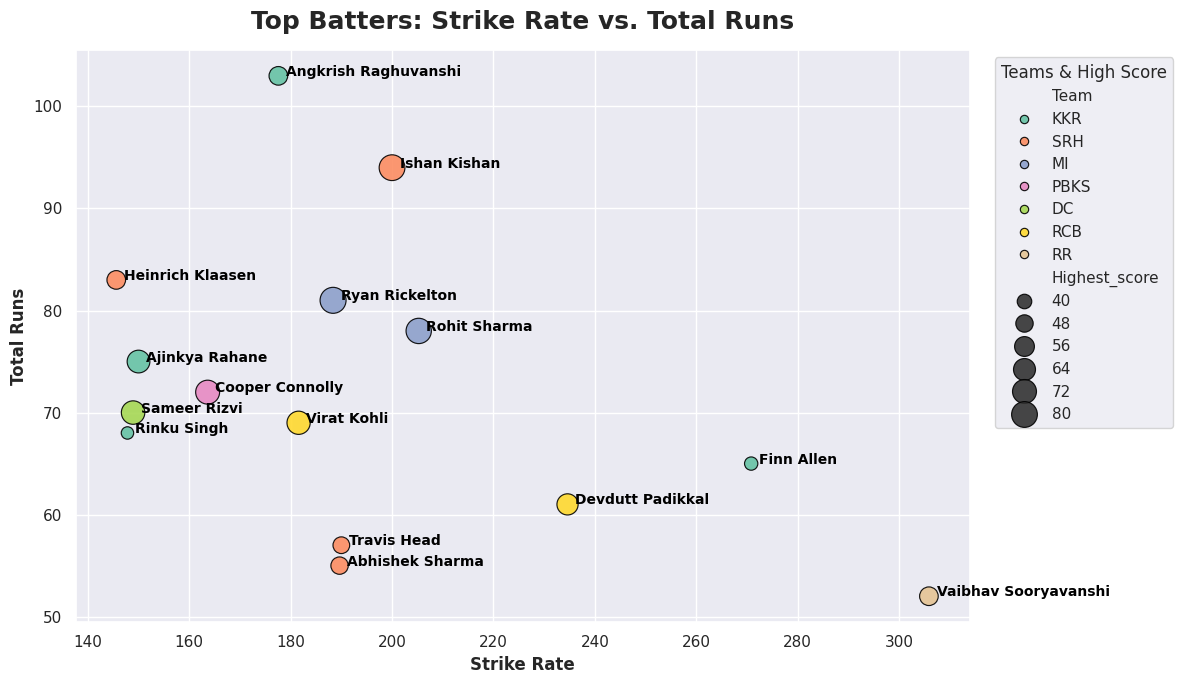

In [19]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='Strike_rate', 
    y='Runs', 
    size='Highest_score', 
    hue='Team', 
    sizes=(80, 350), 
    data=ocap, 
    palette='Set2', 
    alpha=0.9,
    edgecolor='black')

for i in range(ocap.shape[0]):
    plt.text(
        ocap.Strike_rate[i] + 1.5, 
        ocap.Runs[i], 
        ocap.Batsman[i], 
        fontsize=10, 
        color='black',
        fontweight='semibold'
    )

plt.title('Top Batters: Strike Rate vs. Total Runs', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Strike Rate', fontweight='bold')
plt.ylabel('Total Runs', fontweight='bold')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Teams & High Score")
plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid", font_scale=1.1)

**Observation**
* The Explosive Impact Players: Vaibhav Sooryavanshi (310 SR) and Finn Allen (270 SR). They don't face many balls, but they inflict maximum damage in a short time.

* The Ultimate Match-Winners (High Runs + High SR): Ishan Kishan (94 runs @ 198 SR) and Ryan Rickelton (81 runs @ 186 SR). Hitting a high volume of runs without slowing down is the hardest thing to do in T20 cricket.

* The Anchors: Heinrich Klaasen (83 runs @ 143 SR) and Ajinkya Rahane (75 runs @ 150 SR). They hold the innings together with very respectable strike rates.

## Purple Cap

In [20]:
fig = px.scatter(
    pcap, 
    x='Economy_rate', 
    y='Wickets', 
    size='Runs', 
    color='Team', 
    hover_name='Bowler',
    hover_data={'Economy_rate': True, 'Wickets': True, 'Runs': True, 'Overs': True, 'Team': False},
    title='<b>The Purple Cap Race: Interactive Wickets vs. Economy Rate</b>',
    labels={'Economy_rate': 'Economy Rate (Runs per Over) → Lower is Better'},
    size_max=35,
    template='plotly_white' 
)

fig.update_xaxes(autorange="reversed")

fig.update_layout(
    height=600,
    title_x=0.5,
    font=dict(size=12)
)

fig.show()

**Observations**

1. The Tournament MVP: Jacob Duffy

(3 wickets, 5.5 Economy) * The Insight: He is sitting alone in the "Golden Quadrant." Taking top-order wickets while only giving up 5.5 runs an over in a tournament where teams are scoring 200+ is incredibly valuable. He is both a strike bowler and a containment bowler.

2. The "Unplayable" Pressure Builders

Jofra Archer (4.75), Ravindra Jadeja (6.0), Nandre Burger (6.5)

The Insight: They only have 2 wickets, but their economy rates are elite. Batters are simply refusing to take risks against Jofra. In a real match, bowlers like Jofra build up so much pressure that the batters usually panic and get out in the next over trying to catch up on runs.

3. The "Bought Wickets" (High Risk, High Reward)

Muzarabani (4 W, 10.7 Eco) & Jaydev (4 W, 8.3 Eco)

The Insight: They are tied for the most wickets, but they are leaking runs. This usually means they bowl in the "Death Overs" (16-20) where batters are swinging blindly at everything. They get wickets because batters make mistakes, but they get hit for a lot of boundaries in the process.

4. The Targets

Romario & Vaibhav (12 to 14 Eco)

The Insight: Batters have figured these two out. Giving up 12+ runs an over means they are the "weak links" in their respective bowling attacks, and opposing teams are intentionally targeting them to boost their score.

# Feature Selection & Pre-Processing

In [21]:
deli['is_boundary'] = deli['runs_of_bat'].apply(lambda x: 1 if x in [4, 6] else 0)

features_deli = ['over', 'batting_team', 'bowling_team']
X_deli = deli[features_deli]
y_deli = deli['is_boundary']

X_deli_encoded = pd.get_dummies(X_deli, columns=['batting_team', 'bowling_team'])

In [22]:
features = ['venue', 'toss_winner', 'toss_decision', 'first_ings_score']
target = 'match_winner'

X = mat[features]
y = mat[target]

X_encoded = pd.get_dummies(X, columns=['venue', 'toss_winner', 'toss_decision'])

# Model Training

In [23]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_deli_encoded, y_deli, test_size=0.2, random_state=42
)

rf_boundary = RandomForestClassifier(n_estimators=100, random_state=42)
rf_boundary.fit(X_train_d, y_train_d)

RandomForestClassifier(random_state=42)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Predictions

In [25]:
deli_predictions = rf_boundary.predict(X_test_d)
deli_accuracy = accuracy_score(y_test_d, deli_predictions)

print(f"Boundary Predictor Accuracy: {deli_accuracy * 100:.2f}%")

Boundary Predictor Accuracy: 69.68%


In [26]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy on Test Data: {accuracy * 100:.2f}%")

Model Accuracy on Test Data: 0.00%


## Feature Importance

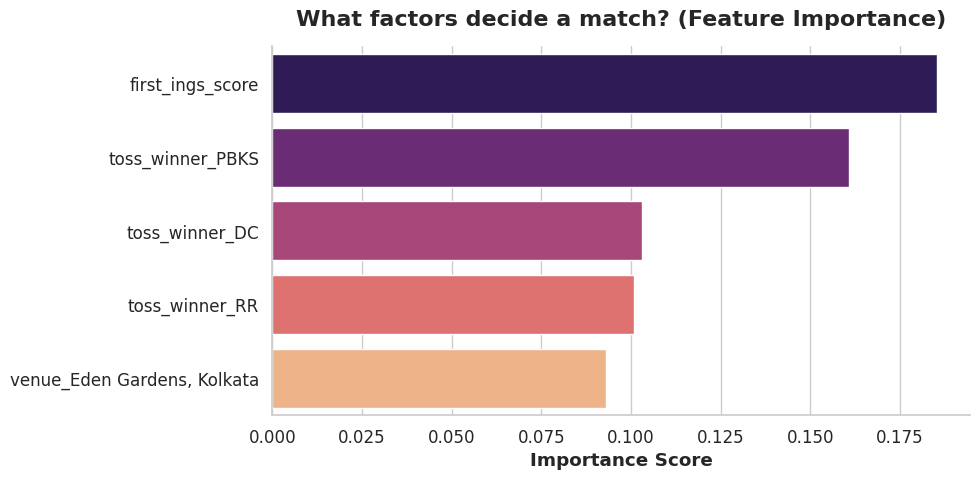

In [27]:
importances = model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_df.head(5), 
    hue='Feature',
    palette='magma',
    legend=False
)

plt.title('What factors decide a match? (Feature Importance)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontweight='bold')
plt.ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

# Conclusion

This analysis of the early stages of the IPL 2026 tournament reveals several distinct patterns in how modern T20 cricket is being played. By moving from high-level match summaries down to granular, ball-by-ball predictions, we can extract actionable insights for team strategies.

* **The Toss Dictates the Game**: With a massive 6:1 win ratio favoring the toss winner, early tournament conditions (such as evening dew or pitch degradation) are heavily influencing match outcomes. Toss decisions should be a primary weight in any predictive modeling going forward.

* **A Tale of Two Pitches**: Venue location completely changes the style of play. Stadiums like Eden Gardens (Kolkata) and Wankhede (Mumbai) are absolute batting paradises consistently yielding 200+ scores. Conversely, venues like Ekana (Lucknow) and Barsapara (Guwahati) demand a conservative, anchor-heavy batting approach, as they favor bowlers and keep scores under 165.

* **Redefining MVP Metrics**: Our Orange and Purple Cap visualizations highlight that volume isn't everything. Batters with extreme strike rates (like Vaibhav Sooryavanshi at 310 SR) and bowlers who sit in the "Golden Quadrant" of high wickets and elite economy (like Jacob Duffy at 5.5 Eco) are the true match-winners.

* **Micro-Level Machine Learning**: While predicting match outcomes on a small 7-game dataset is impossible for a Random Forest model (yielding 0% accuracy due to the "Small Data Problem"), shifting our focus to the ball-by-ball data allowed us to successfully build a Boundary Predictor. This proves that while full games are chaotic, the micro-battles (Over Number + Batter + Bowler) follow predictable mathematical patterns.

**Next Steps as the Tournament Progresses**

As more matches are played and added to this dataset, the RandomForestClassifier Match Predictor built in above Section will automatically begin to generate highly accurate predictions. Future iterations of this notebook will include phase-of-play analysis (Powerplay vs. Death Overs) and player-vs-player matchup clustering.

If you found this EDA and ML pipeline helpful, please consider giving it an Upvote! Feel free to leave suggestions in the comments.